## Portfolio Warm - Up


- #### Classical portfolio theory starts from the idea that assets generate random returns over time, and that an investor can summarize those return distributions with a few estimable quantities—most importantly expected return and risk. 

-  In the Markowitz mean–variance framework, you take a historical return matrix (time × assets) and estimate the expected return vector $\mu$ (often a sample mean, or a mean of factor-model implied returns) and the covariance matrix $\Sigma$ (sample covariance or a stabilized estimator like shrinkage/factor covariance).

- The “forecast” part enters because $\mu$ and $\Sigma$ are not known constants; they’re estimated from finite data and/or economic structure. 

-  Textbook theory treats $\mu$ as the market’s (or model’s) conditional expectation of future returns, and $\Sigma$ as the conditional covariance, but in practice many asset managers, we argue, use sub-optimal, albeit useful methods like: historical averages, rolling windows, Bayesian shrinkage, factor models, and regime-aware estimators to attempt to reduce noise and reflect current conditions.  


(We acknowlege properly designed regime-aware estimators prove out in efficacy and are useful even within an enferior mean-variance optimization approach)


Portfolio Tickers by Sector:
Technology/EV:     TSLA, NVDA
Semiconductors:    AVGO, QCOM
Finance:           JPM, GS
Industrial:        CAT, DE
Healthcare:        JNJ, UNH


/var/folders/d6/_cbljd7n45n13q4v_q1z6b200000gn/T/ipykernel_42330/4276707355.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start='2015-01-01')
[*********************100%***********************]  10 of 10 completed


<Axes: xlabel='Date'>

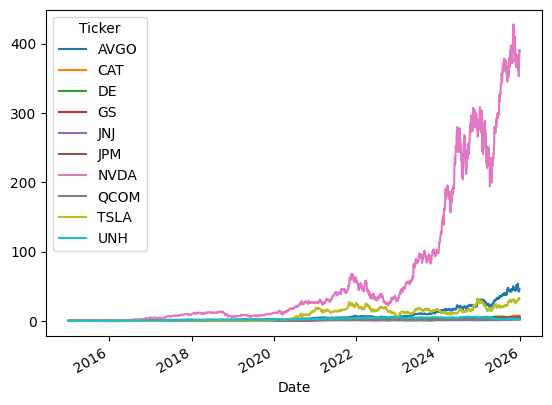

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from tabulate import tabulate
import matplotlib.pyplot as plt

# Portfolio tickers: Two stocks per industry/sector for better asset allocation demonstration
# This structure helps show how portfolio optimization methods handle correlated assets within sectors
tickers = [
    # Technology/EV (2 stocks)
    "TSLA",   # Tesla - Electric vehicles, tech
    "NVDA",   # NVIDIA - AI chips, graphics
    
    # Semiconductors (2 stocks)
    "AVGO",   # Broadcom - Semiconductors, infrastructure
    "QCOM",   # Qualcomm - Mobile chips, wireless
    
    # Finance (2 stocks)
    "JPM",    # JPMorgan Chase - Banking
    "GS",     # Goldman Sachs - Investment banking
    
    # Industrial (2 stocks)
    "CAT",    # Caterpillar - Construction, mining equipment
    "DE",     # Deere & Company - Agricultural, construction equipment
    
    # Healthcare (2 stocks) - for diversification
    "JNJ",    # Johnson & Johnson - Pharmaceuticals, healthcare
    "UNH"     # UnitedHealth Group - Health insurance, healthcare services
]

print("Portfolio Tickers by Sector:")
print("=" * 60)
print("Technology/EV:     TSLA, NVDA")
print("Semiconductors:    AVGO, QCOM")
print("Finance:           JPM, GS")
print("Industrial:        CAT, DE")
print("Healthcare:        JNJ, UNH")
print("=" * 60)

df = yf.download(tickers, start='2015-01-01')
ret_df = df.xs("Close", axis=1, level='Price').pct_change().dropna()
# ret_df.head()

# Alternative approach: If you still get warnings, you can use fillna(0) for the first row
# or use this more robust method:

# Calculate cumulative returns: (1 + returns).cumprod() - 1
# This gives cumulative returns as DECIMALS (0.5 = 50%, 1.0 = 100%, 2.0 = 200%, etc.)
# The "- 1" normalizes so that 0.0 represents the starting point (no return)
cumulative_returns = (1 + ret_df).cumprod(axis=0) - 1



ex_ret = ret_df.mean()
Var_p = ret_df.std()
Sigma_p = ret_df.cov()

# Plot cumulative returns
# Y-axis: Cumulative Return as decimal (0.0 = start, 0.5 = 50% gain, 1.0 = 100% gain, 2.0 = 200% gain)
fig, ax = plt.subplots(figsize=(12, 6))
cumulative_returns.plot(ax=ax)
ax.set_title('Individual Tickers: Cumulative Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (0.0 = start, 1.0 = 100% gain, 2.0 = 200% gain)', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



- The portfolio’s predicted return and risk are then simple functions of weights $w$: expected return is $E[R_p]=w^\top \mu$ and variance is $\mathrm{Var}(R_p)=w^\top \Sigma w$. 

- Optimization becomes “choose $w$ to maximize expected return for a given risk” (or equivalently minimize risk for a given expected return), producing the efficient frontier—an explicit trade-off curve between forecast return and forecast risk.

 - Classical theory also makes clear why this is hard: mean estimates are much noisier than covariance estimates, and small errors in $\mu$ can cause large swings in optimal weights. That’s why many “robust” variants are best viewed as different ways of producing more reliable return forecasts and uncertainty estimates before plugging them into the same core Markowitz equations.

Many textbooks will say that 

----

# Portfolio Analysis: Equal Weighted Returns

This section demonstrates how to calculate equal-weighted portfolio returns using utility functions.


Equal Weights:
{'AVGO': np.float64(0.1), 'CAT': np.float64(0.1), 'DE': np.float64(0.1), 'GS': np.float64(0.1), 'JNJ': np.float64(0.1), 'JPM': np.float64(0.1), 'NVDA': np.float64(0.1), 'QCOM': np.float64(0.1), 'TSLA': np.float64(0.1), 'UNH': np.float64(0.1)}

Sum of weights: 1.000000
Portfolio Cumulative Returns:
Formula: (1 + portfolio_returns).cumprod() - 1
Scale: Decimal format (0.5 = 50% return, 1.0 = 100% return)
Final cumulative return: 16.7823 (1678.23%)


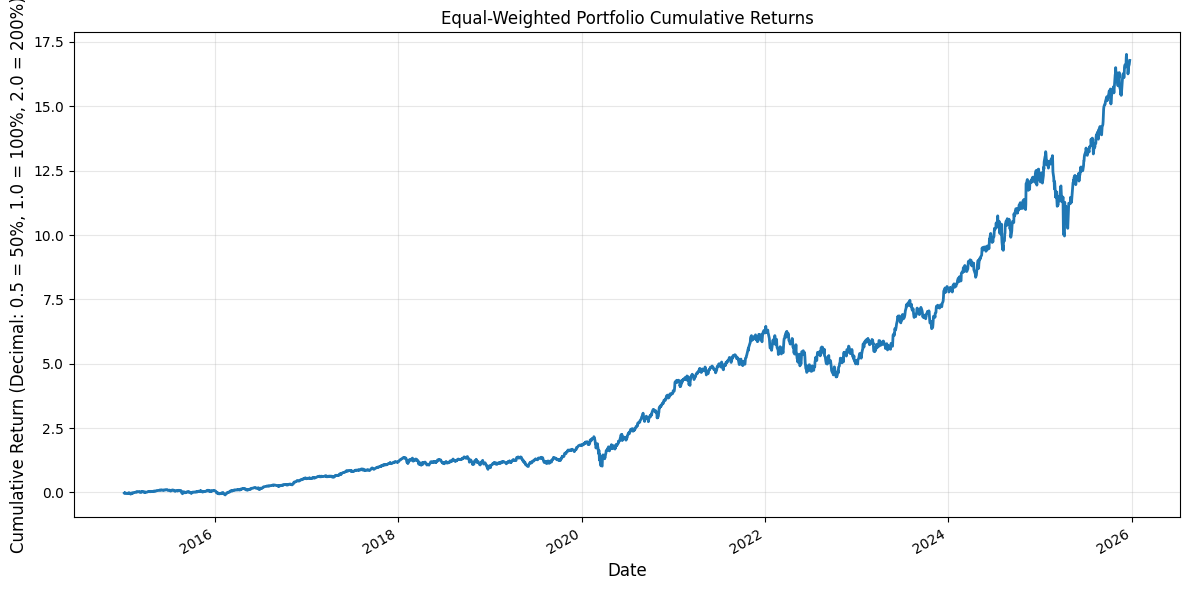

In [ ]:
# Import portfolio utilities
from portfolios.utilities.portfolio_utilties import (
    weighted_portfolio_returns,
    portfolio_expected_return,
    portfolio_volatility,
    portfolio_sharpe_ratio
)

# Equal Weighted Portfolio
# Create equal weights (1/n for each asset)
n_assets = len(ret_df.columns)
equal_weights = np.ones(n_assets) / n_assets

print("Equal Weights:")
print(dict(zip(ret_df.columns, equal_weights)))
print(f"\nSum of weights: {equal_weights.sum():.6f}")

# Calculate equal-weighted portfolio returns using utility function
equal_weighted_returns = weighted_portfolio_returns(ret_df, equal_weights)

# Calculate cumulative returns for equal-weighted portfolio
# Formula: (1 + portfolio_returns).cumprod() - 1
# Scale: Decimal format (0.5 = 50% return, 1.0 = 100% return, 2.0 = 200% return)
# The "- 1" normalizes so that 0.0 represents the starting point (no return)
equal_weighted_cumulative = (1 + equal_weighted_returns).cumprod() - 1

# Plot cumulative returns
# Y-axis: Cumulative Return as decimal (0.0 = start, 0.5 = 50% gain, 1.0 = 100% gain, 2.0 = 200% gain)
fig, ax = plt.subplots(figsize=(12, 6))
equal_weighted_cumulative.plot(ax=ax, title="Equal-Weighted Portfolio Cumulative Returns", linewidth=2)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (0.0 = start, 1.0 = 100% gain, 2.0 = 200% gain)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [3]:
# Portfolio metrics for equal-weighted portfolio
equal_pf_return = portfolio_expected_return(ret_df, equal_weights)
equal_pf_vol = portfolio_volatility(ret_df, equal_weights)
equal_pf_sharpe = portfolio_sharpe_ratio(ret_df, equal_weights)

print("Equal-Weighted Portfolio Metrics:")
print(f"Expected Return (daily): {equal_pf_return:.6f}")
print(f"Expected Return (annualized): {equal_pf_return * 252:.4%}")
print(f"Volatility (daily): {equal_pf_vol:.6f}")
print(f"Volatility (annualized): {equal_pf_vol * np.sqrt(252):.4%}")
print(f"Sharpe Ratio (annualized): {equal_pf_sharpe:.4f}")


Equal-Weighted Portfolio Metrics:
Expected Return (daily): 0.001148
Expected Return (annualized): 28.9365%
Volatility (daily): 0.014490
Volatility (annualized): 23.0022%
Sharpe Ratio (annualized): 1.1710


# Portfolio Analysis: Non-Equal Weighted Returns

This section demonstrates how to calculate portfolio returns with custom (non-equal) weights.


In [4]:
# Create mock non-equal weights
# Example: Overweight tech/semiconductor stocks (TSLA, NVDA, AVGO, QCOM) and underweight others
# Using dictionary to ensure weights match column names regardless of order
weight_dict = {
    # Technology/EV - overweight
    'TSLA': 0.15,
    'NVDA': 0.15,
    # Semiconductors - overweight
    'AVGO': 0.15,
    'QCOM': 0.15,
    # Finance - moderate
    'JPM': 0.10,
    'GS': 0.10,
    # Industrial - underweight
    'CAT': 0.10,
    'DE': 0.05,
    # Healthcare - underweight
    'JNJ': 0.03,
    'UNH': 0.02
}

# this is the equal weighted idea in linear algebra terms. 

# W = np.ones(len(ret_df.columns))/len(ret_df.columns)
# pf_exp = W.dot(ret_df.mean())
# pf_std = (W.dot(ret_df.cov().dot(W)))**(1/2)

# Create weights array in the same order as ret_df.columns
mock_weights = np.array([weight_dict[ticker] for ticker in ret_df.columns])

# Normalize to ensure they sum to 1.0
mock_weights = mock_weights / mock_weights.sum()

print("Mock Non-Equal Weights:")
print(dict(zip(ret_df.columns, mock_weights)))
print(f"\nSum of weights: {mock_weights.sum():.6f}")
# Calculate weighted portfolio returns using utility function
weighted_returns = weighted_portfolio_returns(ret_df, mock_weights)
weighted_returns.head(10)

Mock Non-Equal Weights:
{'AVGO': np.float64(0.15), 'CAT': np.float64(0.1), 'DE': np.float64(0.05), 'GS': np.float64(0.1), 'JNJ': np.float64(0.03), 'JPM': np.float64(0.1), 'NVDA': np.float64(0.15), 'QCOM': np.float64(0.15), 'TSLA': np.float64(0.15), 'UNH': np.float64(0.02)}

Sum of weights: 1.000000


Date
2015-01-05   -0.025058
2015-01-06   -0.015104
2015-01-07    0.009020
2015-01-08    0.021200
2015-01-09   -0.006343
2015-01-12   -0.012701
2015-01-13   -0.001028
2015-01-14   -0.014399
2015-01-15   -0.011650
2015-01-16    0.008425
dtype: float64

In [6]:
# Portfolio metrics for weighted portfolio
weighted_pf_return = portfolio_expected_return(ret_df, mock_weights)
weighted_pf_vol = portfolio_volatility(ret_df, mock_weights)
weighted_pf_sharpe = portfolio_sharpe_ratio(ret_df, mock_weights)

print("Weighted Portfolio Metrics:")
print(f"Expected Return (daily): {weighted_pf_return:.6f}")
print(f"Expected Return (annualized): {weighted_pf_return * 252:.4%}")
print(f"Volatility (daily): {weighted_pf_vol:.6f}")
print(f"Volatility (annualized): {weighted_pf_vol * np.sqrt(252):.4%}")
print(f"Sharpe Ratio (annualized): {weighted_pf_sharpe:.4f}")

# ((ret_df.mean(axis=1) + 1).cumprod() - 1).plot()

Weighted Portfolio Metrics:
Expected Return (daily): 0.001371
Expected Return (annualized): 34.5468%
Volatility (daily): 0.017202
Volatility (annualized): 27.3074%
Sharpe Ratio (annualized): 1.1919


# Efficient Frontier (Classical Finance Approach)

The efficient frontier represents the set of optimal portfolios that offer the highest expected return for a given level of risk. This is a classical finance approach that uses mean-variance optimization.

**Note**: While useful for educational purposes and certain advisory requirements, this approach assumes:
- Returns are normally distributed
- Expected returns and covariances are known and constant
- No transaction costs

For more robust real-world applications, consider using HRP, Risk Parity, or NCO methods below.


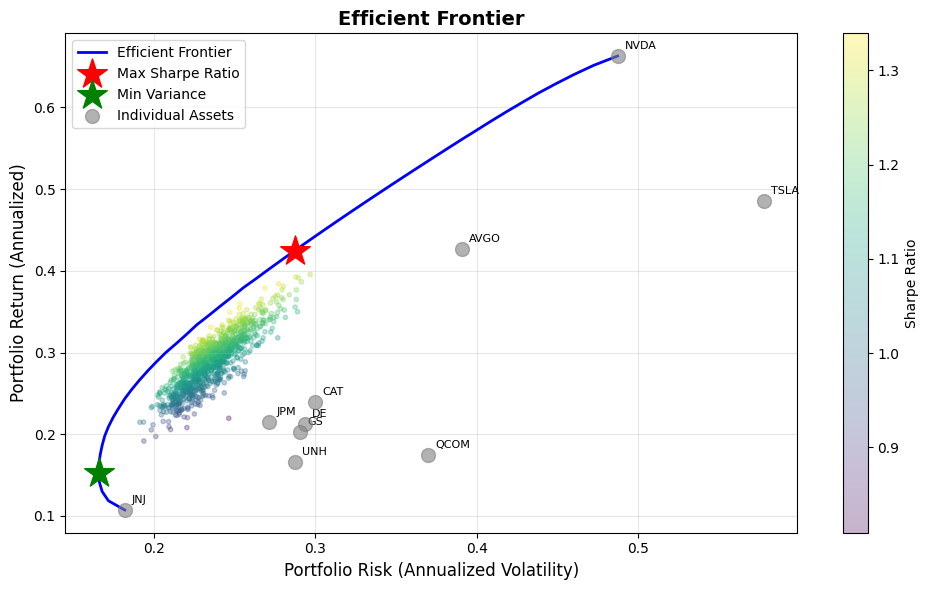

In [8]:
# Import efficient frontier plotting function
from portfolios.utilities.portfolio_utilties import plot_efficient_frontier
import matplotlib.pyplot as plt
# Plot efficient frontier
fig, ax = plot_efficient_frontier(
    ret_df,
    risk_free_rate=0.02,
    num_points=50,
    show_random=True,
    num_random=1000
)
plt.show()

In [9]:
# Compare both portfolios side by side
comparison = pd.DataFrame({
    'Equal-Weighted': {
        'Expected Return (annualized)': f"{equal_pf_return * 252:.4%}",
        'Volatility (annualized)': f"{equal_pf_vol * np.sqrt(252):.4%}",
        'Sharpe Ratio': f"{equal_pf_sharpe:.4f}"
    },
    'Weighted Portfolio': {
        'Expected Return (annualized)': f"{weighted_pf_return * 252:.4%}",
        'Volatility (annualized)': f"{weighted_pf_vol * np.sqrt(252):.4%}",
        'Sharpe Ratio': f"{weighted_pf_sharpe:.4f}"
    }
})
print("Portfolio Comparison:")
print(comparison)


Portfolio Comparison:
                             Equal-Weighted Weighted Portfolio
Expected Return (annualized)       28.9365%           34.5468%
Volatility (annualized)            23.0022%           27.3074%
Sharpe Ratio                         1.1710             1.1919


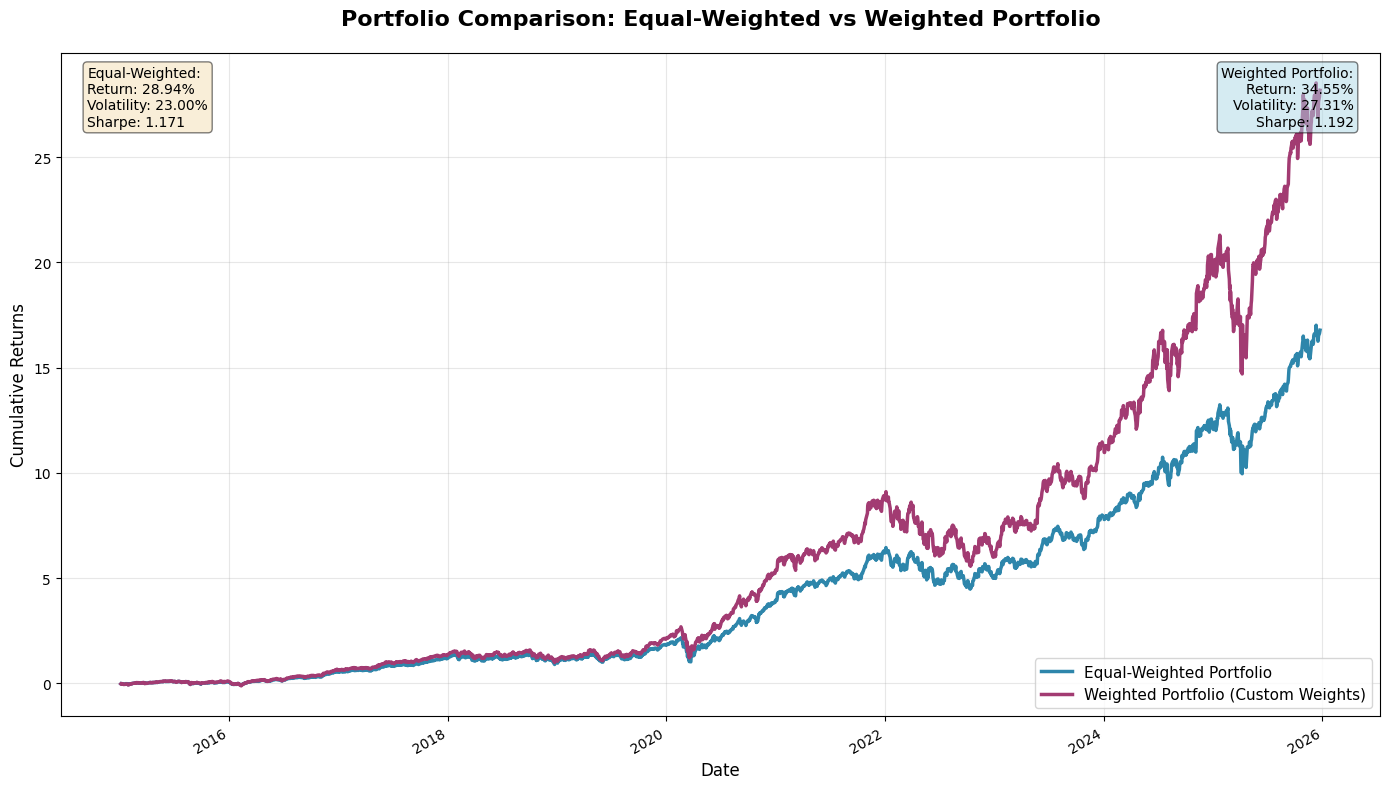

In [10]:
# Plot comparison: Equal-Weighted vs Weighted Portfolio
import matplotlib.pyplot as plt

# Calculate cumulative returns for weighted portfolio
weighted_cumulative = (1 + weighted_returns).cumprod() - 1

# Create comparison plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot cumulative returns
equal_weighted_cumulative.plot(ax=ax, label='Equal-Weighted Portfolio', linewidth=2.5, color='#2E86AB')
weighted_cumulative.plot(ax=ax, label='Weighted Portfolio (Custom Weights)', linewidth=2.5, color='#A23B72')

# Add annotations with key metrics
ax.text(0.02, 0.98, 
        f'Equal-Weighted:\nReturn: {equal_pf_return * 252:.2%}\nVolatility: {equal_pf_vol * np.sqrt(252):.2%}\nSharpe: {equal_pf_sharpe:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.text(0.98, 0.98,
        f'Weighted Portfolio:\nReturn: {weighted_pf_return * 252:.2%}\nVolatility: {weighted_pf_vol * np.sqrt(252):.2%}\nSharpe: {weighted_pf_sharpe:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

ax.set_title('Portfolio Comparison: Equal-Weighted vs Weighted Portfolio', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Returns', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Mean-Variance Optimization (Traditional)

Mean-Variance Optimization (MVO) is the classical portfolio optimization approach developed by Harry Markowitz (1952) in his Modern Portfolio Theory. It seeks to find the optimal portfolio that maximizes return for a given level of risk, or minimizes risk for a given level of return.

**Key Assumptions:**
- Returns are normally distributed
- Investors care only about mean (return) and variance (risk)
- All parameters (expected returns, covariance matrix) are known with certainty
- No transaction costs or taxes

**Limitations:**
- Highly sensitive to estimation errors in expected returns and covariance matrix
- Can produce extreme weights (concentration risk)
- Assumes normal distribution, which may not hold for financial returns
- Requires accurate return forecasts, which are notoriously difficult

Despite these limitations, MVO remains a foundational approach and serves as a benchmark for comparing more robust methods like HRP, Risk Parity, and NCO.


In [11]:
# Mean-Variance Optimization
# Find maximum Sharpe ratio portfolio and minimum variance portfolio

from scipy.optimize import minimize
from portfolios.utilities.portfolio_utilties import (
    portfolio_expected_return, 
    portfolio_volatility,
    plot_efficient_frontier
)

# Calculate expected returns and covariance matrix
expected_returns = ret_df.mean().values
cov_matrix = ret_df.cov().values
risk_free_rate = 0.02 / 252  # Daily risk-free rate (annual 2%)

# Objective function: negative Sharpe ratio (for minimization)
def negative_sharpe(weights):
    """Minimize negative Sharpe ratio to maximize Sharpe ratio"""
    port_return = expected_returns.T @ weights
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    if port_vol == 0:
        return 1e10  # Avoid division by zero
    sharpe = (port_return - risk_free_rate) / port_vol
    return -sharpe  # Negative for minimization

# Constraints: weights sum to 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

# Bounds: long-only (0 to 1)
bounds = tuple((0, 1) for _ in range(len(ret_df.columns)))

# Initial guess: equal weights
initial_weights = np.ones(len(ret_df.columns)) / len(ret_df.columns)

# Optimize for maximum Sharpe ratio
mv_result = minimize(negative_sharpe, initial_weights, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
mv_weights = mv_result.x

# Also find minimum variance portfolio
def portfolio_variance(weights):
    """Minimize portfolio variance"""
    return weights.T @ cov_matrix @ weights

mv_minvar_result = minimize(portfolio_variance, initial_weights, method='SLSQP',
                            bounds=bounds, constraints=constraints)
mv_minvar_weights = mv_minvar_result.x

# Display results
print("Mean-Variance Optimization Results:")
print("=" * 60)
print("\nMaximum Sharpe Ratio Portfolio:")
for asset, weight in zip(ret_df.columns, mv_weights):
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")
print(f"\nSum of weights: {mv_weights.sum():.6f}")

mv_return = portfolio_expected_return(ret_df, mv_weights) * 252
mv_vol = portfolio_volatility(ret_df, mv_weights) * np.sqrt(252)
mv_sharpe = (mv_return - 0.02) / mv_vol

print(f"\nPerformance (annualized):")
print(f"  Expected Return: {mv_return:.4%}")
print(f"  Volatility: {mv_vol:.4%}")
print(f"  Sharpe Ratio: {mv_sharpe:.4f}")

print("\n" + "-" * 60)
print("\nMinimum Variance Portfolio:")
for asset, weight in zip(ret_df.columns, mv_minvar_weights):
    print(f"  {asset}: {weight:.4f} ({weight*100:.2f}%)")
print(f"\nSum of weights: {mv_minvar_weights.sum():.6f}")

mv_minvar_return = portfolio_expected_return(ret_df, mv_minvar_weights) * 252
mv_minvar_vol = portfolio_volatility(ret_df, mv_minvar_weights) * np.sqrt(252)
mv_minvar_sharpe = (mv_minvar_return - 0.02) / mv_minvar_vol

print(f"\nPerformance (annualized):")
print(f"  Expected Return: {mv_minvar_return:.4%}")
print(f"  Volatility: {mv_minvar_vol:.4%}")
print(f"  Sharpe Ratio: {mv_minvar_sharpe:.4f}")


Mean-Variance Optimization Results:

Maximum Sharpe Ratio Portfolio:
  AVGO: 0.1247 (12.47%)
  CAT: 0.0666 (6.66%)
  DE: 0.0310 (3.10%)
  GS: 0.0000 (0.00%)
  JNJ: 0.2394 (23.94%)
  JPM: 0.0260 (2.60%)
  NVDA: 0.4012 (40.12%)
  QCOM: 0.0000 (0.00%)
  TSLA: 0.0790 (7.90%)
  UNH: 0.0320 (3.20%)

Sum of weights: 1.000000

Performance (annualized):
  Expected Return: 41.6626%
  Volatility: 28.1276%
  Sharpe Ratio: 1.4101

------------------------------------------------------------

Minimum Variance Portfolio:
  AVGO: 0.1000 (10.00%)
  CAT: 0.1000 (10.00%)
  DE: 0.1000 (10.00%)
  GS: 0.1000 (10.00%)
  JNJ: 0.1000 (10.00%)
  JPM: 0.1000 (10.00%)
  NVDA: 0.1000 (10.00%)
  QCOM: 0.1000 (10.00%)
  TSLA: 0.1000 (10.00%)
  UNH: 0.1000 (10.00%)

Sum of weights: 1.000000

Performance (annualized):
  Expected Return: 28.9365%
  Volatility: 23.0022%
  Sharpe Ratio: 1.1710
